In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, floor, sqrt
df=pd.read_csv('aapl_2016_2020.csv',low_memory=False)

In [24]:
df.columns

Index(['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]',
       ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]',
       ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]',
       ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]',
       ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]',
       ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]',
       ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]',
       ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]'],
      dtype='object')

In [25]:
df.columns = df.columns.str.strip().str.lower().str.replace('[\\[\\]]', '', regex=True)
df['quote_date'] = pd.to_datetime(df['quote_date'])
df['expire_date'] = pd.to_datetime(df['expire_date'])
# aapl=df.drop(columns=['quote_unixtime', 'expire_unix', 'quote_readtime','quote_time_hours','c_volume'])


In [27]:
df=df[(df['quote_date']<='2019-01-01') & (df['expire_date']<='2019-01-01')]

Opened Iron Condor on 2016-01-04 expiring 2016-02-05 | Credit: 27.00 | Capital: 100027.00
  Put Spread: 85.0 / 90.0 | Call Spread: 119.0 / 120.0
Opened Iron Condor on 2016-01-04 expiring 2016-02-19 | Credit: 59.00 | Capital: 100086.00
  Put Spread: 85.0 / 90.0 | Call Spread: 120.0 / 125.0
Opened Iron Condor on 2016-01-05 expiring 2016-01-22 | Credit: 34.00 | Capital: 100120.00
  Put Spread: 90.0 / 95.0 | Call Spread: 111.0 / 112.0
Opened Iron Condor on 2016-01-05 expiring 2016-01-29 | Credit: 30.00 | Capital: 100150.00
  Put Spread: 85.0 / 90.0 | Call Spread: 115.0 / 116.0
Opened Iron Condor on 2016-01-05 expiring 2016-02-05 | Credit: 22.00 | Capital: 100172.00
  Put Spread: 80.0 / 85.0 | Call Spread: 116.0 / 117.0
Opened Iron Condor on 2016-01-05 expiring 2016-02-12 | Credit: 25.00 | Capital: 100197.00
  Put Spread: 80.0 / 85.0 | Call Spread: 117.0 / 118.0
Opened Iron Condor on 2016-01-05 expiring 2016-02-19 | Credit: 42.00 | Capital: 100239.00
  Put Spread: 80.0 / 85.0 | Call Spread:

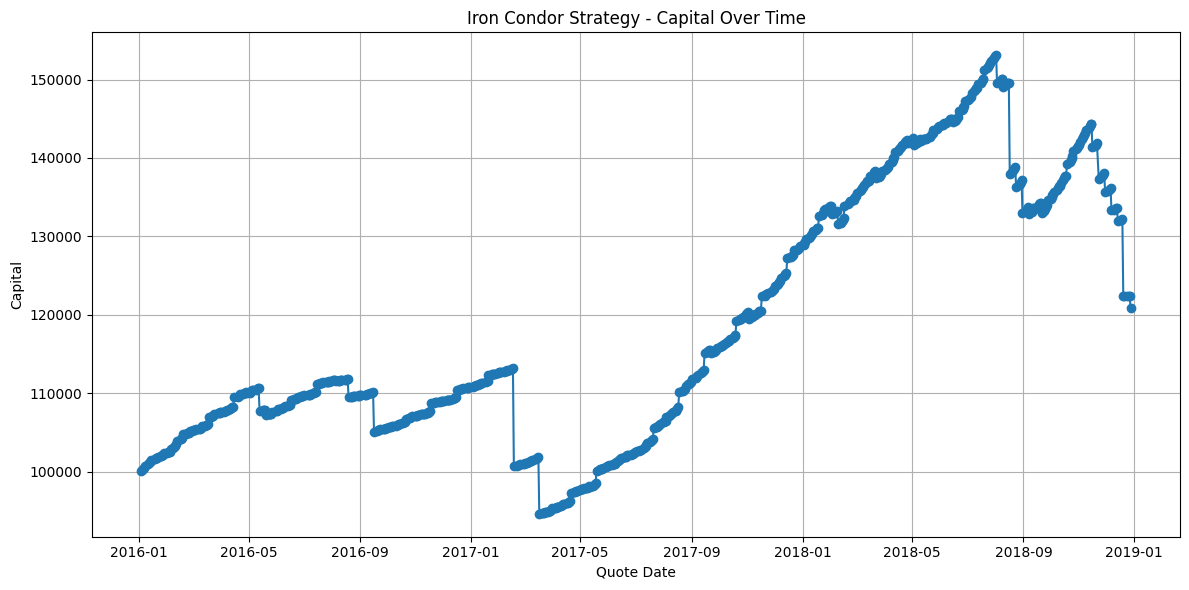


Performance Summary:
Initial Capital: $100000.00
Final Capital: $120834.00
Total Return: 20.83%
Number of Trades: 2123
Win Rate: 78.80%


In [28]:
TRADING_DAYS = 252
LOT_SIZE = 100
MAX_POSITIONS = 100

# Initialize capital and trade tracker
capital = 100000
capital_history = [capital]
date_history = []
open_trades = []
closed_trades = []

# Assume df is your main DataFrame with all data, sorted by quote_date
df['quote_date'] = pd.to_datetime(df['quote_date'])
df['expire_date'] = pd.to_datetime(df['expire_date'])
to_numeric_cols = ['underlying_last', 'dte', 'c_iv', 'p_iv', 'c_bid', 'c_ask', 'p_bid', 'p_ask', 'strike']
for col in to_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for quote_date in sorted(df['quote_date'].unique()):
    daily_data = df[df['quote_date'] == quote_date]

    for expiry in sorted(daily_data['expire_date'].unique()):
        if expiry <= quote_date:
            continue  # Skip if expire_date is not in the future

        if len(open_trades) >= MAX_POSITIONS:
            break  # Limit number of open positions

        expiry_data = daily_data[daily_data['expire_date'] == expiry]
        if expiry_data.empty:
            continue
        
        dte = expiry_data['dte'].iloc[0]
        if dte >= 70:  # Skip if days to expiry is too long
            continue
            
        underlying = expiry_data['underlying_last'].iloc[0]
        
        # Find ATM strike (closest to current price)
        available_strikes = sorted(expiry_data['strike'].unique())
        atm_strike = min(available_strikes, key=lambda x: abs(x - underlying))
        
        atm_row = expiry_data[expiry_data['strike'] == atm_strike]
        if atm_row.empty:
            continue

        # Calculate expected move based on IV
        iv = (atm_row['c_iv'].values[0] + atm_row['p_iv'].values[0]) / 2
        expected_move = underlying * iv * sqrt(dte / TRADING_DAYS)
        
        # Define our Iron Condor wings based on expected move
        lower_bound = underlying - expected_move
        upper_bound = underlying + expected_move
        
        # Find appropriate strikes for our iron condor
        # For a proper iron condor:
        # 1. Short put strike should be below expected move
        # 2. Long put strike should be below short put
        # 3. Short call strike should be above expected move
        # 4. Long call strike should be above short call
        
        # Get available strikes sorted
        available_strikes = sorted(expiry_data['strike'].unique())
        
        # Find put strikes (below expected move)
        put_strikes = [strike for strike in available_strikes if strike < lower_bound]
        if len(put_strikes) < 2:
            continue  # Need at least 2 strikes for put spread
        
        # Short put (higher strike of put spread)
        put_sell_strike = max(put_strikes)
        put_sell = expiry_data[expiry_data['strike'] == put_sell_strike]
        
        # Long put (lower strike of put spread)
        put_buy_strike = max([s for s in put_strikes if s < put_sell_strike])
        put_buy = expiry_data[expiry_data['strike'] == put_buy_strike]
        
        # Find call strikes (above expected move)
        call_strikes = [strike for strike in available_strikes if strike > upper_bound]
        if len(call_strikes) < 2:
            continue  # Need at least 2 strikes for call spread
        
        # Short call (lower strike of call spread)
        call_sell_strike = min(call_strikes)
        call_sell = expiry_data[expiry_data['strike'] == call_sell_strike]
        
        # Long call (higher strike of call spread)
        call_buy_strike = min([s for s in call_strikes if s > call_sell_strike])
        call_buy = expiry_data[expiry_data['strike'] == call_buy_strike]
        
        # Check if we have valid spreads
        if put_sell.empty or put_buy.empty or call_sell.empty or call_buy.empty:
            continue
            
        # Calculate credits
        p_credit = put_sell['p_bid'].values[0] - put_buy['p_ask'].values[0]
        c_credit = call_sell['c_bid'].values[0] - call_buy['c_ask'].values[0]
        
        # Check if both spreads are profitable
        if p_credit <= 0 or c_credit <= 0:
            continue
            
        # Calculate total credit
        total_credit = (p_credit + c_credit) * LOT_SIZE
        
        # Implement minimum credit requirement
        if total_credit < 20:
            continue
            
        # Calculate max risk (width of spread minus credit received)
        put_width = (put_sell_strike - put_buy_strike) * LOT_SIZE
        call_width = (call_buy_strike - call_sell_strike) * LOT_SIZE
        max_risk = max(put_width, call_width) - total_credit
        
        # Record trade
        trade = {
            'quote_date': quote_date,
            'expire_date': expiry,
            'underlying_entry': underlying,
            'put_sell_strike': put_sell_strike,
            'put_buy_strike': put_buy_strike,
            'call_sell_strike': call_sell_strike,
            'call_buy_strike': call_buy_strike,
            'volume': LOT_SIZE,
            'credit': total_credit,
            'max_risk': max_risk,
            'put_width': put_width,
            'call_width': call_width
        }
        
        open_trades.append(trade)
        capital += total_credit  # Add credit to capital

        print(f"Opened Iron Condor on {quote_date.date()} expiring {expiry.date()} | Credit: {total_credit:.2f} | Capital: {capital:.2f}")
        print(f"  Put Spread: {put_buy_strike} / {put_sell_strike} | Call Spread: {call_sell_strike} / {call_buy_strike}")

    # Check for expiry and close trades
    expired_trades = [t for t in open_trades if t['expire_date'] == quote_date]
    for trade in expired_trades:
        final_price = df[(df['quote_date'] == quote_date)]['underlying_last'].iloc[0]
        loss = 0

        # Calculate actual P&L at expiration
        if final_price < trade['put_buy_strike']:
            # Max loss on put spread
            loss = trade['put_width']
        elif final_price < trade['put_sell_strike']:
            # Partial loss on put spread
            loss = (trade['put_sell_strike'] - final_price) * LOT_SIZE 
        elif final_price > trade['call_buy_strike']:
            # Max loss on call spread
            loss = trade['call_width']
        elif final_price > trade['call_sell_strike']:
            # Partial loss on call spread
            loss = (final_price - trade['call_sell_strike']) * LOT_SIZE
            
        # Adjust by the credit received
        net_pnl = trade['credit'] - loss
        
        capital += net_pnl  # Add P&L to capital
        
        # Record closed trade
        trade['final_price'] = final_price
        trade['loss'] = loss
        trade['net_pnl'] = net_pnl
        closed_trades.append(trade)
        open_trades.remove(trade)

        print(f"Closed Iron Condor from {trade['quote_date'].date()} | Expired {trade['expire_date'].date()} | PnL: {net_pnl:.2f} | Capital: {capital:.2f}")

    # Track capital history
    capital_history.append(capital)
    date_history.append(quote_date)

# Plot capital curve
plt.figure(figsize=(12, 6))
plt.plot(date_history, capital_history[1:], marker='o')
plt.title("Iron Condor Strategy - Capital Over Time")
plt.xlabel("Quote Date")
plt.ylabel("Capital")
plt.grid(True)
plt.tight_layout()
plt.show()

# Performance metrics
initial_capital = capital_history[0]
final_capital = capital_history[-1]
total_return = (final_capital / initial_capital - 1) * 100
num_trades = len(closed_trades)
profitable_trades = sum(1 for t in closed_trades if t['net_pnl'] > 0)
win_rate = profitable_trades / num_trades * 100 if num_trades > 0 else 0

print(f"\nPerformance Summary:")
print(f"Initial Capital: ${initial_capital:.2f}")
print(f"Final Capital: ${final_capital:.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Win Rate: {win_rate:.2f}%")

Opened trade on 2016-01-08 expiring 2016-02-12 | Credit: 25.00 | Capital: 100025.00
Opened trade on 2016-01-14 expiring 2016-02-05 | Credit: 21.00 | Capital: 100046.00
Opened trade on 2016-01-21 expiring 2016-02-26 | Credit: 21.00 | Capital: 100067.00
Opened trade on 2016-01-22 expiring 2016-02-26 | Credit: 22.00 | Capital: 100089.00
Closed trade from 2016-01-14 | Expired 2016-02-05 | PnL: 0.00 | Capital: 100089.00
Opened trade on 2016-02-08 expiring 2016-03-24 | Credit: 33.00 | Capital: 100122.00
Opened trade on 2016-02-09 expiring 2016-03-24 | Credit: 35.00 | Capital: 100157.00
Closed trade from 2016-01-08 | Expired 2016-02-12 | PnL: 0.00 | Capital: 100157.00
Closed trade from 2016-01-21 | Expired 2016-02-26 | PnL: 0.00 | Capital: 100157.00
Closed trade from 2016-01-22 | Expired 2016-02-26 | PnL: 0.00 | Capital: 100157.00
Closed trade from 2016-02-08 | Expired 2016-03-24 | PnL: 0.00 | Capital: 100157.00
Closed trade from 2016-02-09 | Expired 2016-03-24 | PnL: 0.00 | Capital: 100157.0

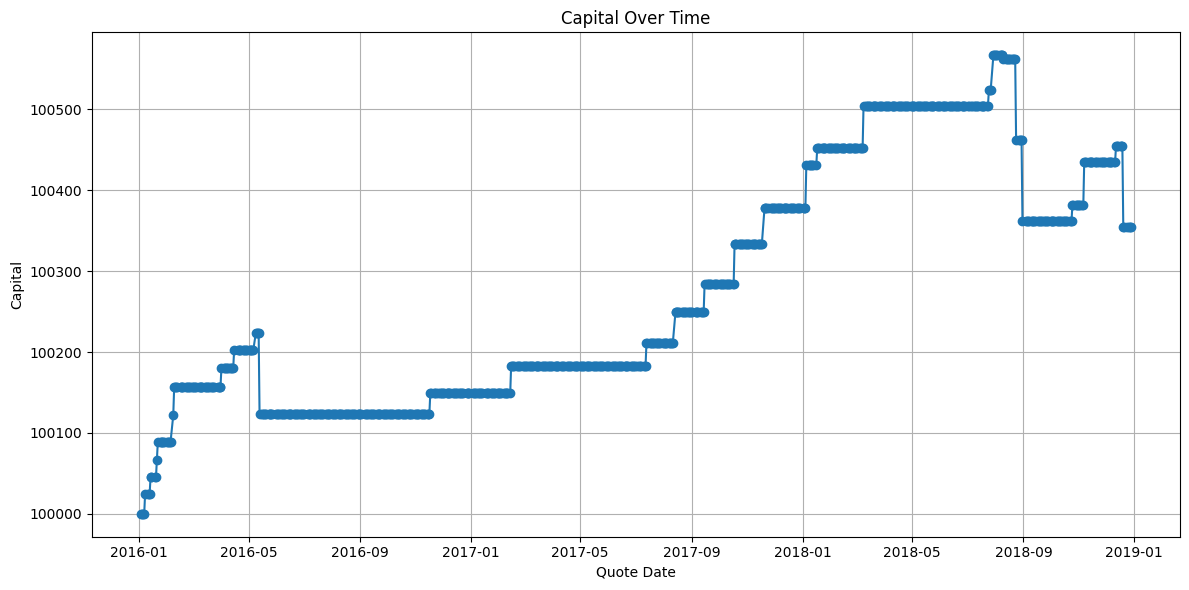


Final capital: 100355.00


In [ ]:
# TRADING_DAYS = 252
# LOT_SIZE = 100
# MAX_POSITIONS = 50

# # Initialize capital and trade tracker
# capital = 100000
# capital_history = [capital]
# date_history = []
# open_trades = []
# closed_trades = []

# # Assume df is your main DataFrame with all data, sorted by quote_date
# df['quote_date'] = pd.to_datetime(df['quote_date'])
# df['expire_date'] = pd.to_datetime(df['expire_date'])
# to_numeric_cols = ['underlying_last', 'dte', 'c_iv', 'p_iv', 'c_bid', 'c_ask', 'p_bid', 'p_ask', 'strike']
# for col in to_numeric_cols:
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# for quote_date in sorted(df['quote_date'].unique()):
#     daily_data = df[df['quote_date'] == quote_date]

#     for expiry in sorted(daily_data['expire_date'].unique()):
#         if expiry <= quote_date:
#             continue  # Skip if expire_date is not in the future

#         if len(open_trades) >= MAX_POSITIONS:
#             break  # Limit number of open positions

#         expiry_data = daily_data[daily_data['expire_date'] == expiry]
#         if expiry_data.empty:
#             continue
        

#         dte = expiry_data['dte'].iloc[0]
#         if dte>=70:
#             continue
#         underlying = expiry_data['underlying_last'].iloc[0]
#         atm_strike = ceil(underlying)

#         atm_row = expiry_data[expiry_data['strike'] == atm_strike]
#         if atm_row.empty:
#             continue

#         iv = (atm_row['c_iv'].values[0] + atm_row['p_iv'].values[0]) / 2
#         expected_move = underlying * iv * sqrt(dte / TRADING_DAYS)

#         lower_bound = floor(underlying - expected_move)-3
#         upper_bound = ceil(underlying + expected_move)+3

#         # Put spread
#         put_sell = expiry_data[(expiry_data['strike'] <= lower_bound)]
#         put_buy = expiry_data[(expiry_data['strike'] <= lower_bound - 1)]

#         put_sell = put_sell.sort_values(by='strike', ascending=False).head(1)
#         put_buy = put_buy.sort_values(by='strike', ascending=False).head(1)

#         if not put_sell.empty and not put_buy.empty:
#             p_credit = put_sell['p_bid'].values[0] - put_buy['p_ask'].values[0]
#             if p_credit <= 0:
#                 continue  # Not profitable
#             # Call spread
#             call_sell = expiry_data[(expiry_data['strike'] >= upper_bound)]
#             call_buy = expiry_data[(expiry_data['strike'] >= upper_bound + 1)]

#             call_sell = call_sell.sort_values(by='strike').head(1)
#             call_buy = call_buy.sort_values(by='strike').head(1)

#             if not call_sell.empty and not call_buy.empty:
#                 c_credit = call_sell['c_bid'].values[0] - call_buy['c_ask'].values[0]
#                 if c_credit <= 0:
#                     continue  # Not profitable
#                 total_credit = (p_credit + c_credit) * LOT_SIZE 
#                 if total_credit < 20:
#                     continue
#                 # Record trade
#                 trade = {
#                     'quote_date': quote_date,
#                     'expire_date': expiry,
#                     'underlying_entry': underlying,
#                     'put_sell_strike': put_sell['strike'].values[0],
#                     'put_buy_strike': put_buy['strike'].values[0],
#                     'call_sell_strike': call_sell['strike'].values[0],
#                     'call_buy_strike': call_buy['strike'].values[0],
#                     'credit': total_credit
#                 }
#                 open_trades.append(trade)
#                 capital += total_credit

#                 print(f"Opened trade on {quote_date.date()} expiring {expiry.date()} | Credit: {total_credit:.2f} | Capital: {capital:.2f}")

#     # Check for expiry and close trades
#     expired_trades = [t for t in open_trades if t['expire_date'] == quote_date]
#     for trade in expired_trades:
#         final_price = df[(df['quote_date'] == quote_date)]['underlying_last'].iloc[0]
#         loss = 0

#         # Put side
#         if final_price < trade['put_buy_strike']:
#             # beyond long put: max loss = 10000
#             loss += 100
#         elif final_price < trade['put_sell_strike']:
#             # between put sell and buy
#             loss += min((trade['put_sell_strike'] - final_price) * LOT_SIZE , 100)

#         # Call side
#         if final_price > trade['call_buy_strike']:
#             # beyond long call: max loss = 10000
#             loss += 100
#         elif final_price > trade['call_sell_strike']:
#             # between call sell and buy
#             loss += min((final_price - trade['call_sell_strike']) * LOT_SIZE , 100)

#         capital -= loss
#         trade['final_price'] = final_price
#         trade['loss'] = loss
#         closed_trades.append(trade)
#         open_trades.remove(trade)

#         print(f"Closed trade from {trade['quote_date'].date()} | Expired {trade['expire_date'].date()} | PnL: {-loss:.2f} | Capital: {capital:.2f}")

#     # Track capital history
#     capital_history.append(capital)
#     date_history.append(quote_date)

# # Plot capital curve
# plt.figure(figsize=(12, 6))
# plt.plot(date_history, capital_history[1:], marker='o')
# plt.title("Capital Over Time")
# plt.xlabel("Quote Date")
# plt.ylabel("Capital")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# print(f"\nFinal capital: {capital:.2f}")
